# Assignment 3
### Due 9/21. Do four of five.


Sophie Kim 

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# opening data

college = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/college_completion.csv")
college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [28]:
# seeing if there's NAs in control variable 

college['control'].value_counts()

control
Public                    1558
Private not-for-profit    1248
Private for-profit         992
Name: count, dtype: int64

In [29]:
college['control_na'] = college['control'].isna() # seeing if there are NAs
college['control_na'].value_counts() 
# looks good

control_na
False    3798
Name: count, dtype: int64

In [30]:
college['level_na'] = college['level'].isna() # seeing if there are NAs
college['level_na'].value_counts() 
# also good

level_na
False    3798
Name: count, dtype: int64

In [31]:
# contingency table
pd.crosstab( college['control'],college['level'])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


*There is almost double the number of total 4-year colleges versus 2-year colleges. The number of private not-for-profit colleges for 4-year schools is much higher than the number of private not-for-profit colleges for 2-year schools (more than the private for-profit and public 4 year schools combined). On top of that, private not-for-profit schools were the least frequent school type for 2-year scchools.*

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [32]:
nhanes = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/nhanes_data_17_18.csv")
nhanes.head()

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_10886/1804828127.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/nhanes_data_17_18.csv")


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# wanted to make the weight into a categorical variable to see the rough distirubtion of weight

bins = [0, 50, 100, 150, 200, np.inf]
labels = ['0-50', '51-100', '101-150', '151-200', '>200']
nhanes['WeightKg_50Intervals'] = pd.cut(nhanes['WeightKg'], bins=bins, labels=labels, right=False)

pd.crosstab(nhanes['WeightKg_50Intervals'], nhanes['Gender'])

Gender,Female,Male
WeightKg_50Intervals,,
0-50,1139,1007
51-100,2664,2351
101-150,378,629
151-200,27,43
>200,3,1


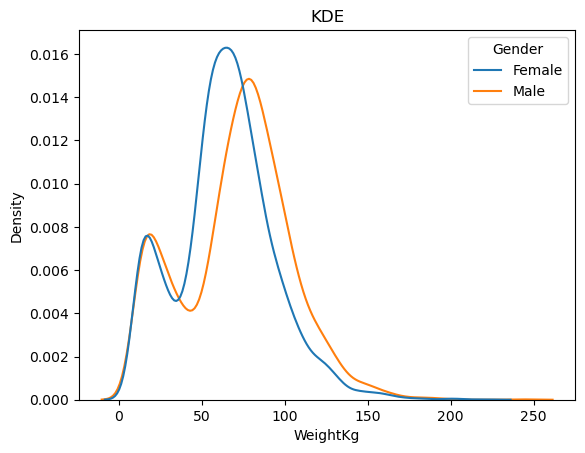

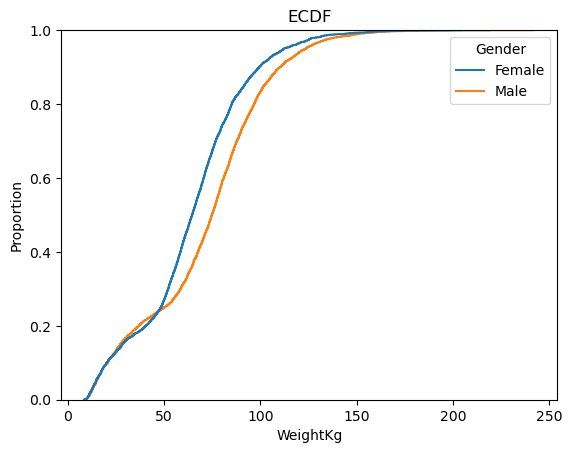

WeightKg                                                     
          count       mean        std  min    25%   50%   75%    max
Gender                                                              
Female   4211.0  64.014652  29.252509  8.3  48.25  64.5  81.0  219.6
Male     4031.0  71.139469  33.066564  8.7  50.10  74.7  92.0  242.6

In [34]:
conditioner = 'Gender'
sns.kdeplot( data=nhanes, x='WeightKg', hue=conditioner, common_norm=False ).set(title='KDE')
plt.show()
sns.ecdfplot( data=nhanes, x='WeightKg', hue=conditioner).set(title='ECDF')
plt.show()
nhanes.loc[:,['WeightKg', conditioner]].groupby(conditioner).describe()

*From the KDE plot, it appears that the highest density of both females and males weigh 50 to 100 kgs. It also appears that more often than not, males weigh more than females (higher density of males in the plot and extends further than female). Both the female and male curves have a smaller peak at roughly 25kg. This indicates that there is a relatively high density of both gender samples that weigh around 25kg. This could likely be children samples in the dataset. The ECDF plot shows similar findings to the KDE plot. Both the male and female curves steepen at roughly 50 to 100 kgs. The male curve being towards the right of the female curve (further on the x axis) indicates that generally, at the given proportion, males weigh more than females. The female curve also reaches 100% quicker than the male curve, which, again, indicates that generally males weigh more than females.*

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

,retain_percentile
aid_percentile,
0.0,35.250000
1.0,35.700000
2.0,56.733333
3.0,34.823529
4.0,37.258065
...,...
96.0,66.405405
97.0,71.054054
98.0,63.526316


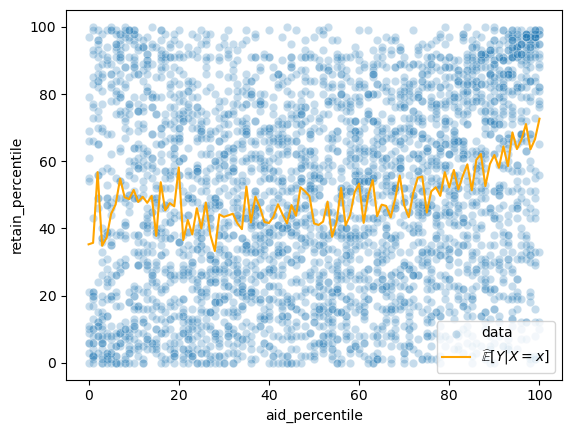

In [41]:
means = college.loc[:,['retain_percentile','aid_percentile']].groupby('aid_percentile').mean()
sns.scatterplot(data=college, y='retain_percentile', x='aid_percentile',alpha=.25, label='data')
sns.lineplot(data=means, x='aid_percentile',y='retain_percentile',color='orange', label='$\\widehat{\\mathbb{E}}[Y|X=x]$')

means

In [42]:
means.diff()

,retain_percentile
aid_percentile,
0.0,NaN
1.0,0.450000
2.0,21.033333
3.0,-21.909804
4.0,2.434535
...,...
96.0,2.794294
97.0,4.648649
98.0,-7.527738


*The relationship between aid_percentile and retain_percentile seems to have a slightly positive linear relationship. Though, there are many dips and peaks in the line, which indicates a possible non-linear relationship, meaning that there are most likely other variables that contribute to an increased retain percentile. In this scenario, I think that the aid_percentile variable does play a role, but there are probably other factors that go into a student staying in college, such as education quality of the specific institution, personal reasons for needing to drop out of college, etc. You can still use this model to predict the retain_percentile depending on aid_percentile becuase when you are predicting, you are simply looking at past data trends to see what could be possible, not why a certain outcome is possible.*